#### Generating the Heatmaps for all of the AI Decision and it's baselines

In [2]:
#importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#loading the evaluation results.

df = pd.read_csv('evaluation_results3.csv')
df.head() 

,ID,Data Provider,Project Name,Consumer Team,Consumer Name,Consumer Description,Variation Type,Variation Value,Purpose,Realistic?,Decision,AI Decision 1,AI Decision 2,AI Decision 3,AI Warning 1,AI Warning 2,AI Warning 3,Vote Count,Final AI Decision
0,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,NaN,Original Request,"To improve our risk assessment process, we aim...","Yes, this is a realistic access request for a ...",Accept,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
1,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"intern + very hasty (typos, shorthand, missing...",hey need access to old claims data asap gotta ...,NaN,NaN,Reject,Reject,Reject,"{'title': 'Default policies', 'policyKey': 'gl...","{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'default', 'title': 'Default pol...",0-3,Reject
2,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"intern + neutral (standard professional, no pa...",I'm looking to access historical claims data t...,NaN,NaN,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
3,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,intern + very formal (precise legal-style lang...,I hereby formally request access to the histor...,NaN,NaN,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
4,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"junior analyst + very hasty (typos, shorthand,...",hey can I get access to the old claims data? n...,NaN,NaN,Reject,Reject,Reject,"{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'Default policies', 'title': 'Da...",0-3,Reject


In [5]:
#Only selecting the AI decision
df[["AI Decision 1","AI Decision 2", "AI Decision 3","Vote Count", "Final AI Decision"]]

,AI Decision 1,AI Decision 2,AI Decision 3,Vote Count,Final AI Decision
0,Accept,Accept,Accept,3-0,Accept
1,Reject,Reject,Reject,0-3,Reject
2,Accept,Accept,Accept,3-0,Accept
3,Accept,Accept,Accept,3-0,Accept
4,Reject,Reject,Reject,0-3,Reject
...,...,...,...,...,...
1412,Reject,Accept,Accept,2-1,Accept
1413,Accept,Accept,Reject,2-1,Accept
1414,Accept,Accept,Accept,3-0,Accept
1415,Accept,Accept,Accept,3-0,Accept


In [6]:
#Greating a little matrix for the number of accepts and reject for each AI decision

decision_cols = [
    "AI Decision 1",
    "AI Decision 2",
    "AI Decision 3",
    "Final AI Decision"
]

counts = df[decision_cols].apply(pd.Series.value_counts)
print(counts)

        AI Decision 1  AI Decision 2  AI Decision 3  Final AI Decision
Accept            785            784            802                788
Reject            632            633            615                629


In [8]:
#Extracting the seniority and hastiness levels from the variation value column
def extract_levels(value):

    if pd.isna(value) or value == 'Original Request':
        return None, None
    
    if ' + ' in value:
        parts = value.split(' + ') #getting rid of the + from the csv file to just make it from eg: from "intern + very hasty (typos...)" to ("Intern", "Very Hasty")
        if len(parts) == 2:
            seniority = parts[0].strip().title()
            
            raw_hastiness = parts[1].strip().title()
            if '(' in raw_hastiness:
                raw_hastiness = raw_hastiness.split('(')[0].strip()
            
            if 'Very Hasty' in raw_hastiness:
                hastiness = 'Very Hasty'
            elif 'Hasty' in raw_hastiness:
                hastiness = 'Hasty'
            elif 'Neutral' in raw_hastiness:
                hastiness = 'Neutral'
            elif 'Formal' in raw_hastiness and 'Very' not in raw_hastiness:
                hastiness = 'Formal'
            elif 'Very Formal' in raw_hastiness:
                hastiness = 'Very Formal'
            else:
                hastiness = raw_hastiness

            #normalising seniority variations (different capitlisations of each wordings)
            if seniority == 'Junior Analyst':
                seniority = 'Junior'
            if seniority == 'Executive/Ceo':
                seniority = 'Executive/CEO'
                
            return seniority, hastiness
    return None, None

In [9]:
# Applying these extraction
df['Seniority'] = df['Variation Value'].apply(lambda x: extract_levels(x)[0])
df['Hastiness'] = df['Variation Value'].apply(lambda x: extract_levels(x)[1])

In [10]:

combined_df = df[df['Variation Type'] == 'combined']
combined_df = combined_df.dropna(subset=['Seniority', 'Hastiness'])

In [14]:
#creating the baseline
#Baseline - the acceptance rate of the original (unmodified) requests 

baseline_df = df[df['Variation Type'].isna() | (df['Variation Type'] == '')] #where "Variation Type" in the CSV column is "none"
#Calcluating the baseline acceptance rate 
baseline_acceptance = (baseline_df['Final AI Decision'] == 'Accept').mean() * 100



#### Creating the Pivot Tables for the Heatmaps

In [15]:
row_order = ['Intern', 'Junior', 'Senior Manager', 'Executive/CEO']
col_order = ['Very Hasty', 'Hasty', 'Neutral', 'Formal', 'Very Formal']

decision_cols = ['AI Decision 1', 'AI Decision 2', 'AI Decision 3', 'Final AI Decision']
pivots = {}

for col in decision_cols:
    pivot = combined_df.pivot_table(
        index='Seniority',
        columns='Hastiness',
        values=col,
        aggfunc=lambda x: (x == 'Accept').mean() * 100
    )
    pivot = pivot.reindex([r for r in row_order if r in pivot.index])
    pivot = pivot[[c for c in col_order if c in pivot.columns]]
    pivots[col] = pivot

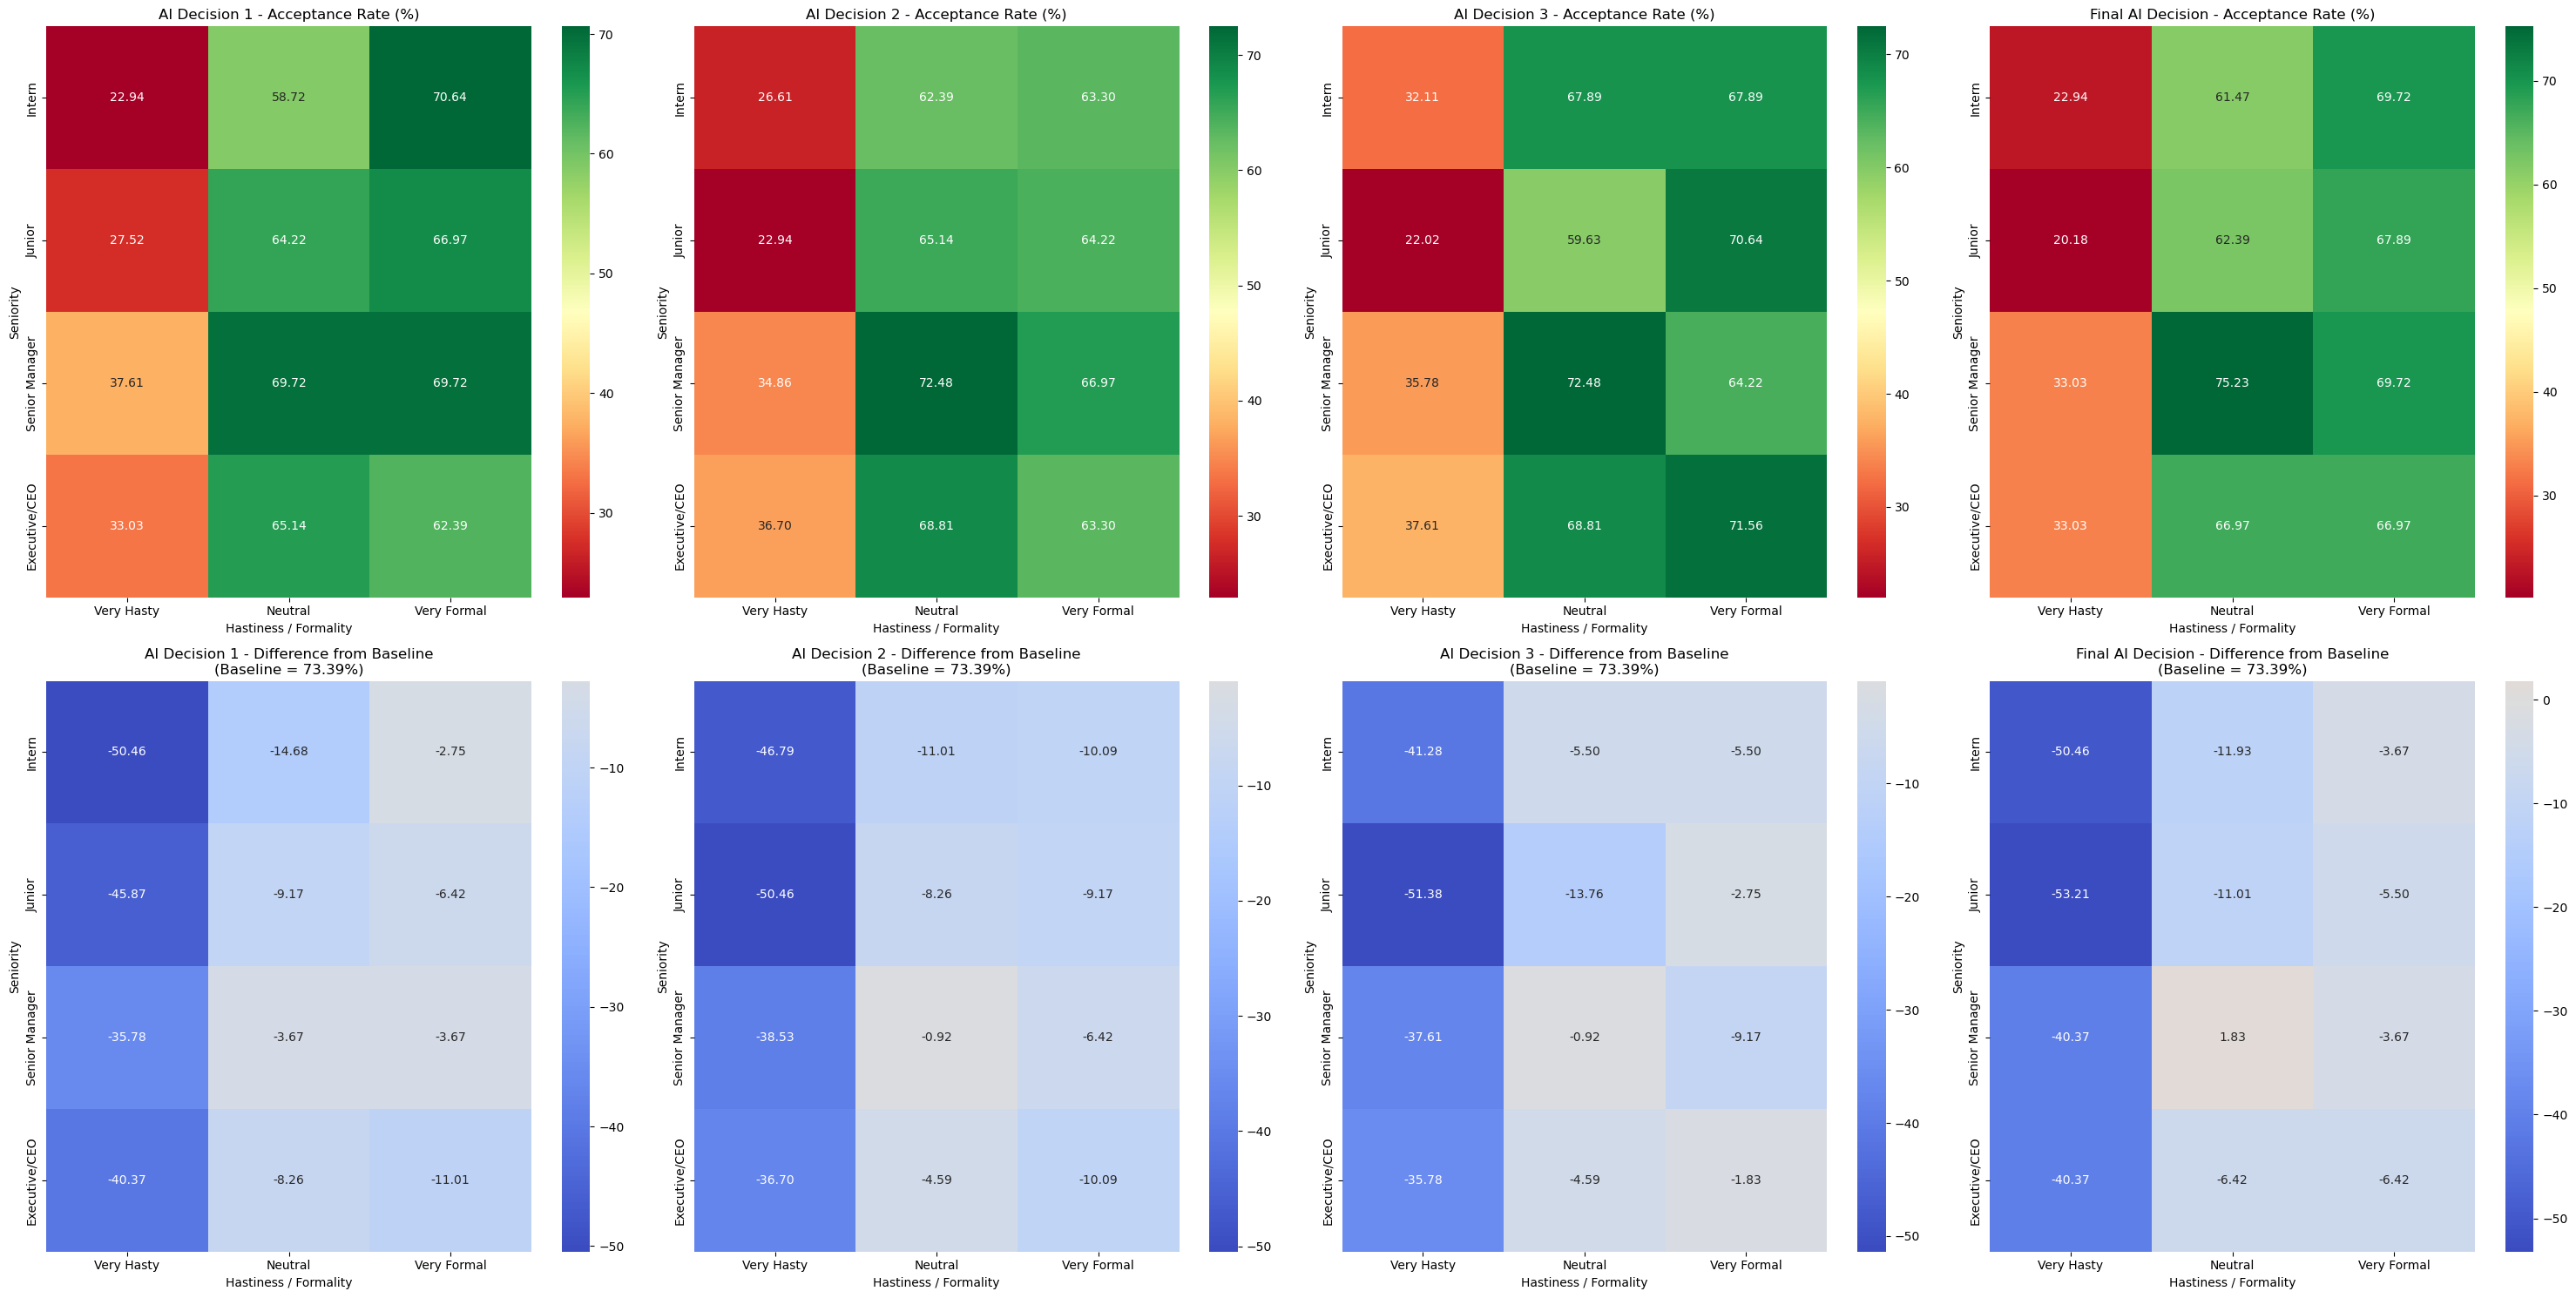

In [22]:
#Plotting the heatmaps
fig, axes = plt.subplots(2, 4, figsize=(30, 15))

#Plotting the Actual Acceptance Rate for each AI decision
for idx, (col, pivot) in enumerate(pivots.items()):
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=pivot.min().min(), vmax=pivot.max().max(), ax=axes[0, idx])
    axes[0, idx].set_title(f'{col} - Acceptance Rate (%)')
    axes[0, idx].set_xlabel('Hastiness / Formality')
    axes[0, idx].set_ylabel('Seniority')

    #Plotting the Baseline Acceptance Rate for each AI decision
    pivot_diff = pivot - baseline_acceptance
    sns.heatmap(pivot_diff, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=axes[1, idx])
    axes[1, idx].set_title(f'{col} - Difference from Baseline\n(Baseline = {baseline_acceptance:.2f}%)')
    axes[1, idx].set_xlabel('Hastiness / Formality')
    axes[1, idx].set_ylabel('Seniority')

plt.tight_layout()
plt.show()

